<a href="https://colab.research.google.com/github/vallurusandeepkumar63-coder/Linear-Regression/blob/main/Guided_project_linear_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd

import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [ ]:
dataset=pd.read_csv("/content/CarPrice_project.csv")

In [ ]:
dataset.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [ ]:
dataset.describe(include='all')

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205,205,205,205,205,205,205,205.000000,...,205.000000,205,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
unique,NaN,NaN,147,2,2,2,5,3,2,NaN,...,NaN,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,peugeot 504,gas,std,four,sedan,fwd,front,NaN,...,NaN,mpfi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,6,185,168,115,96,120,202,NaN,...,NaN,94,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,103.000000,0.834146,NaN,NaN,NaN,NaN,NaN,NaN,NaN,98.756585,...,126.907317,NaN,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,NaN,NaN,NaN,NaN,NaN,NaN,NaN,6.021776,...,41.642693,NaN,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,86.600000,...,61.000000,NaN,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,94.500000,...,97.000000,NaN,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,97.000000,...,120.000000,NaN,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,102.400000,...,141.000000,NaN,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000


In [ ]:
len(dataset[dataset.duplicated()])

0

In [ ]:
dataset.columns

Index(['car_ID', 'symboling', 'CarName', 'fueltype', 'aspiration',
       'doornumber', 'carbody', 'drivewheel', 'enginelocation', 'wheelbase',
       'carlength', 'carwidth', 'carheight', 'curbweight', 'enginetype',
       'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

exploratory data analysis

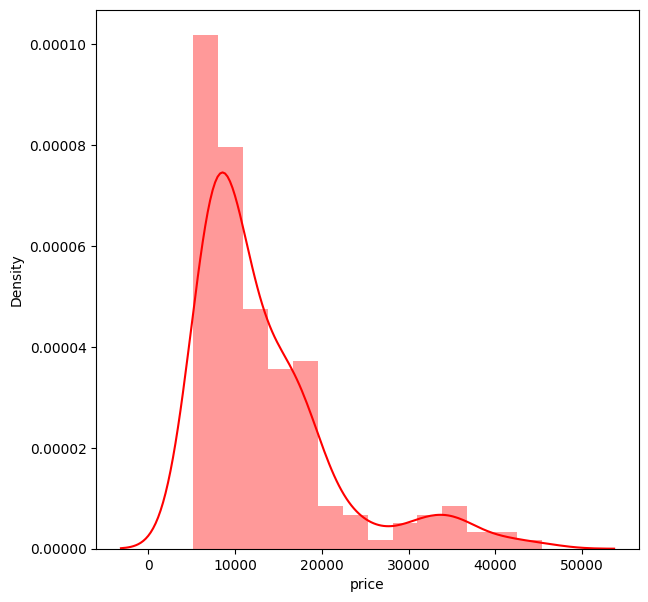

In [ ]:
#dependent variabe price
plt.figure(figsize=(7,7))
sns.distplot(dataset['price'],color="r")
plt.show()

<Figure size 700x700 with 0 Axes>

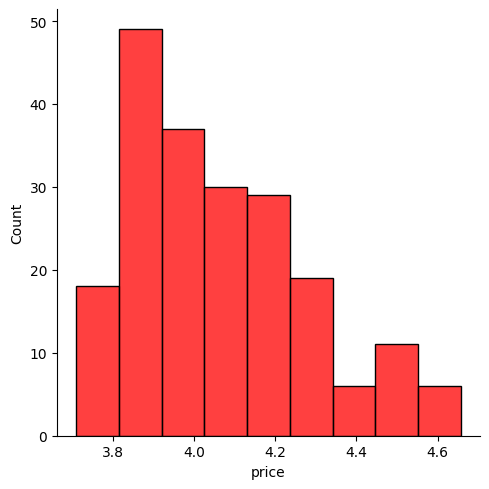

In [ ]:
plt.figure(figsize=(7,7))
sns.displot(np.log10(dataset['price']),color="r")
plt.show()


In [ ]:
numeric_features=dataset.describe().columns
numeric_features

Index(['car_ID', 'symboling', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginesize', 'boreratio', 'stroke',
       'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg',
       'price'],
      dtype='object')

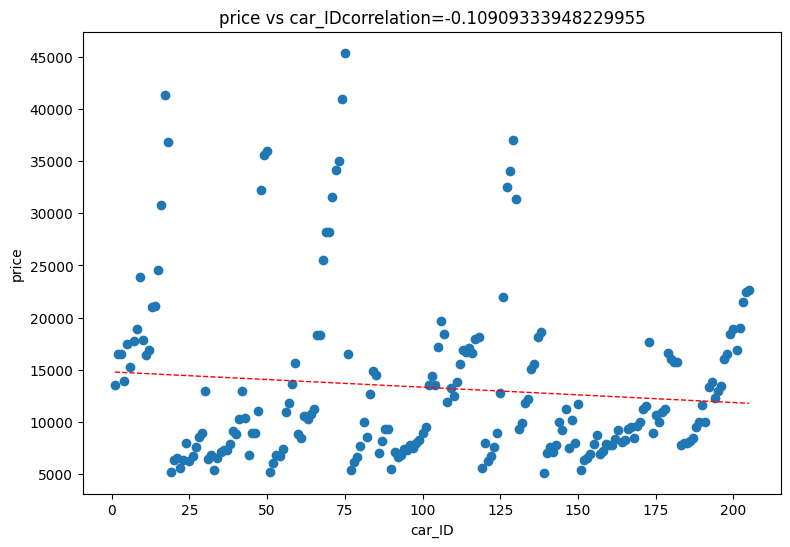

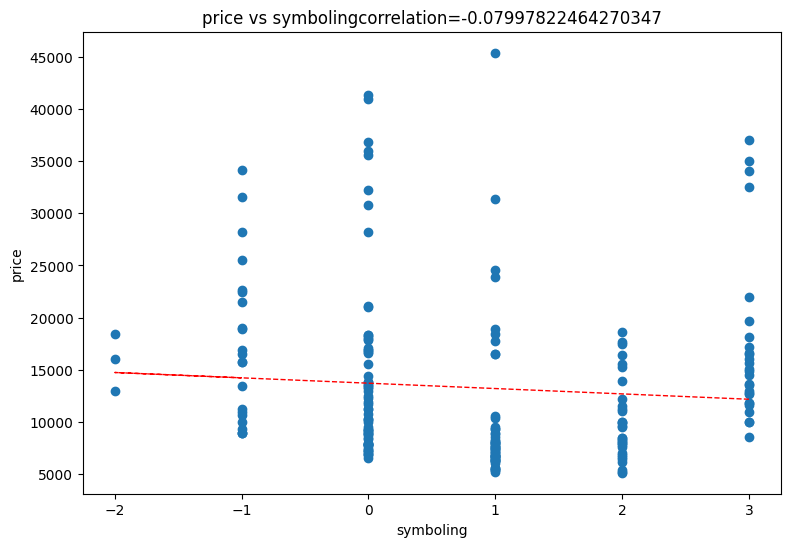

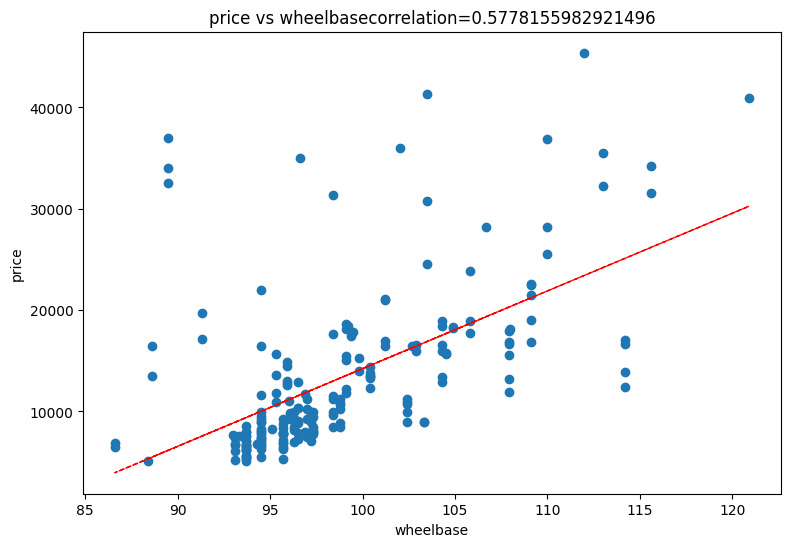

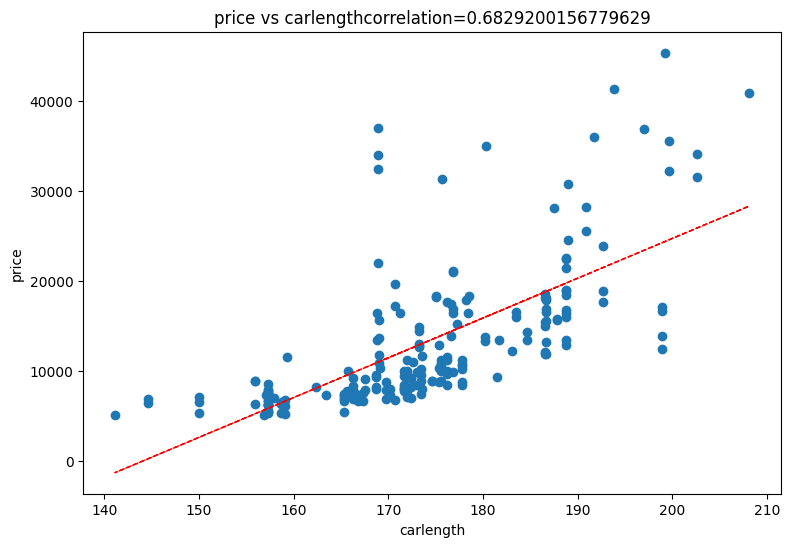

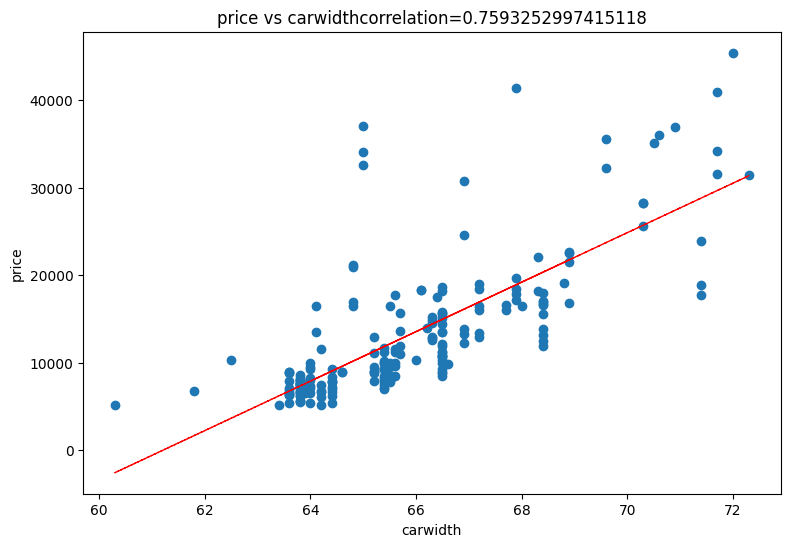

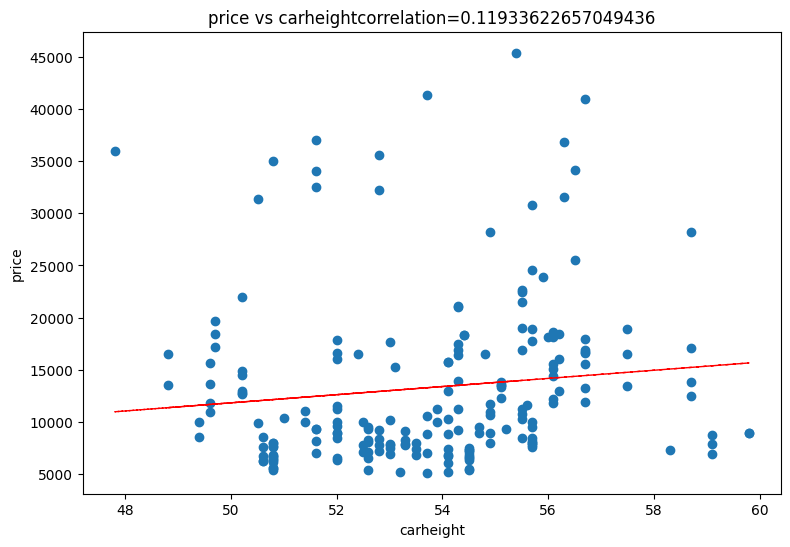

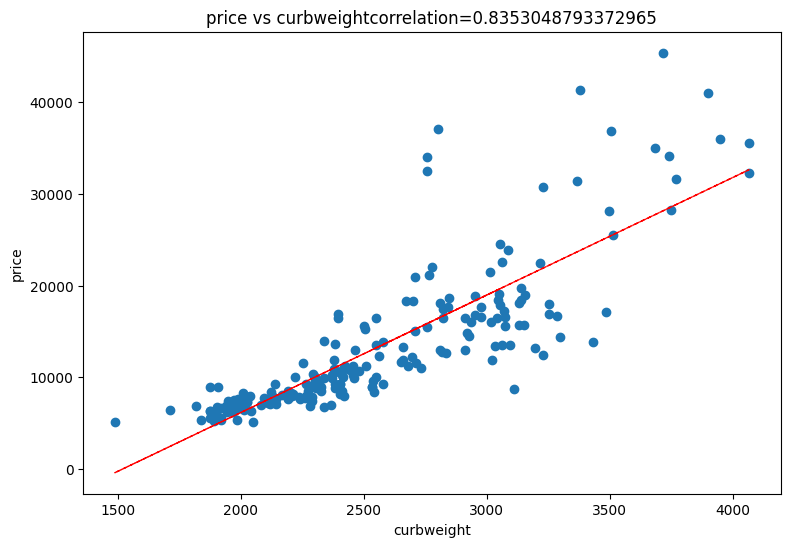

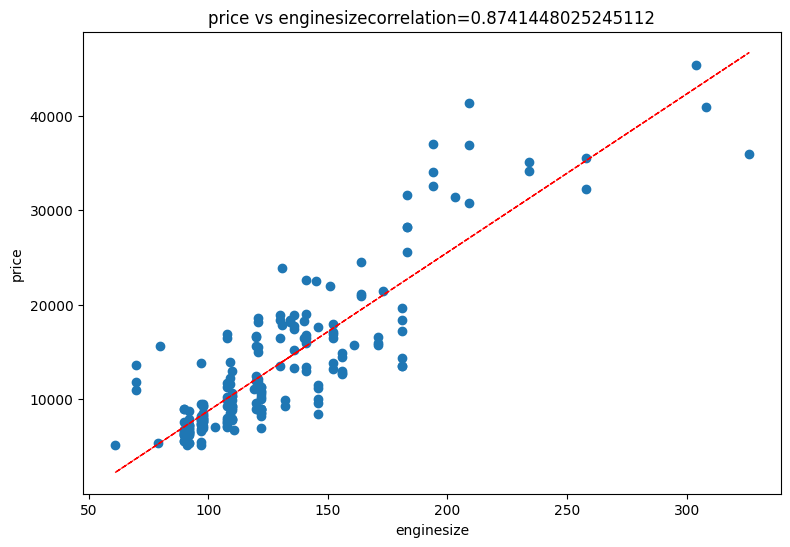

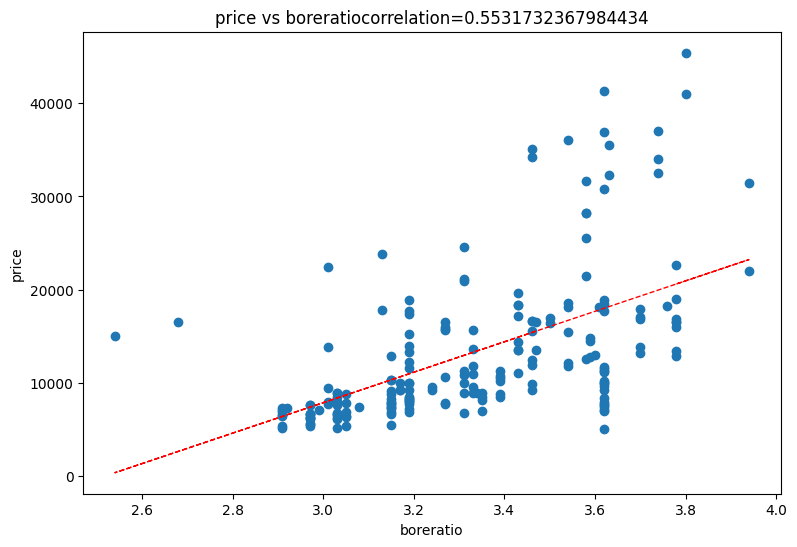

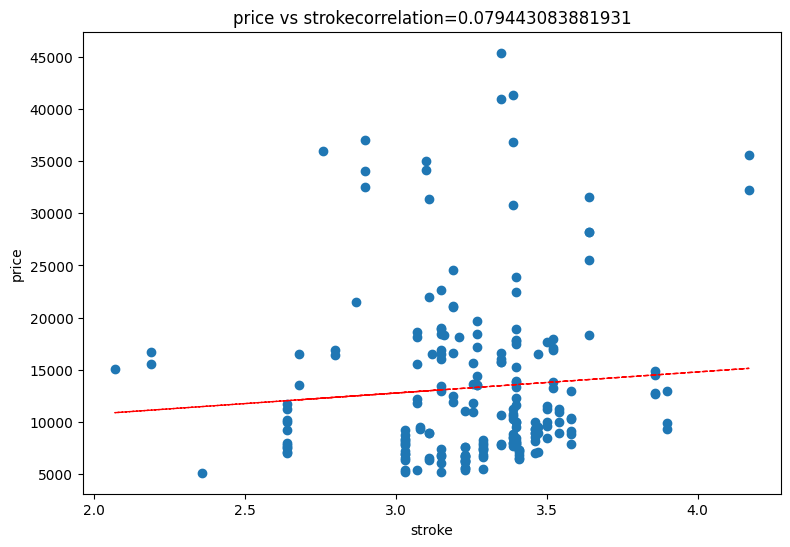

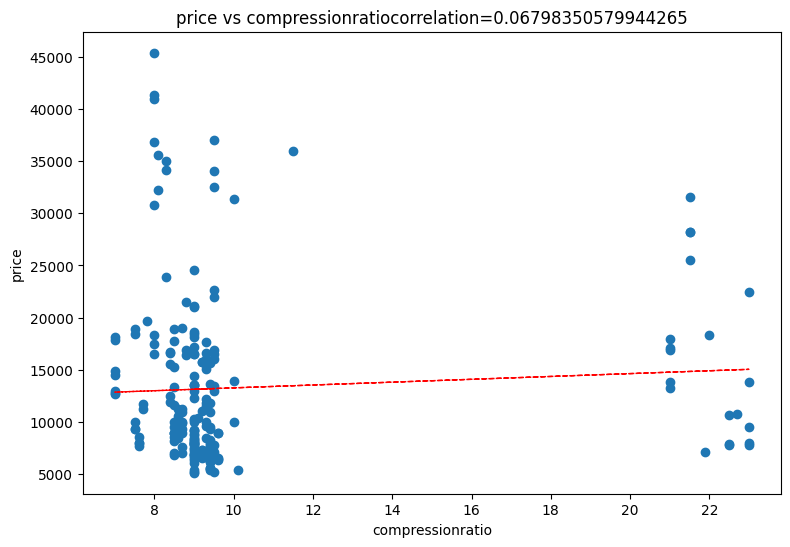

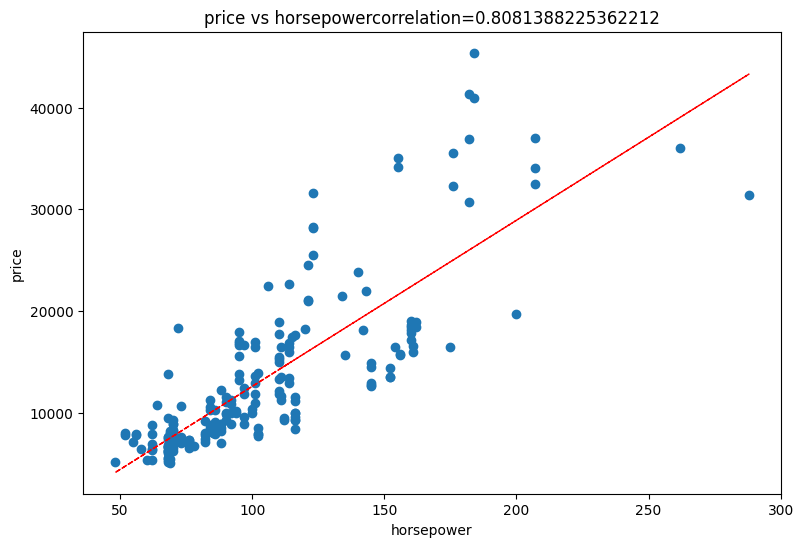

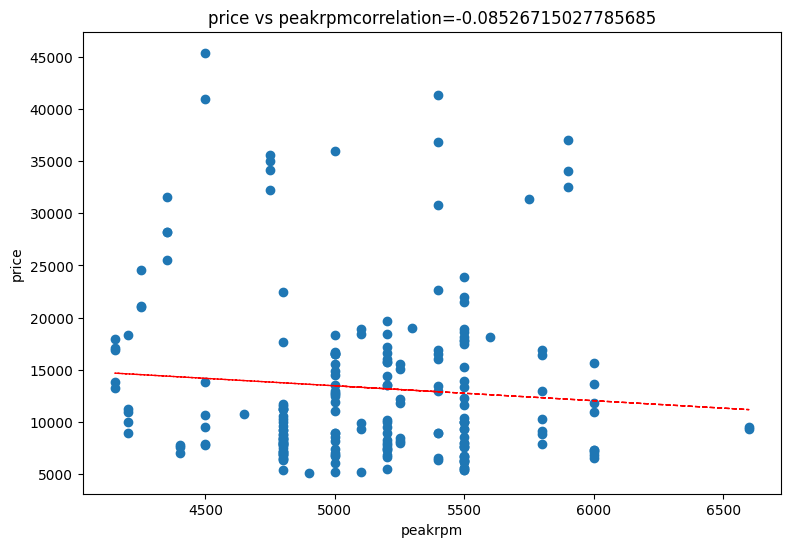

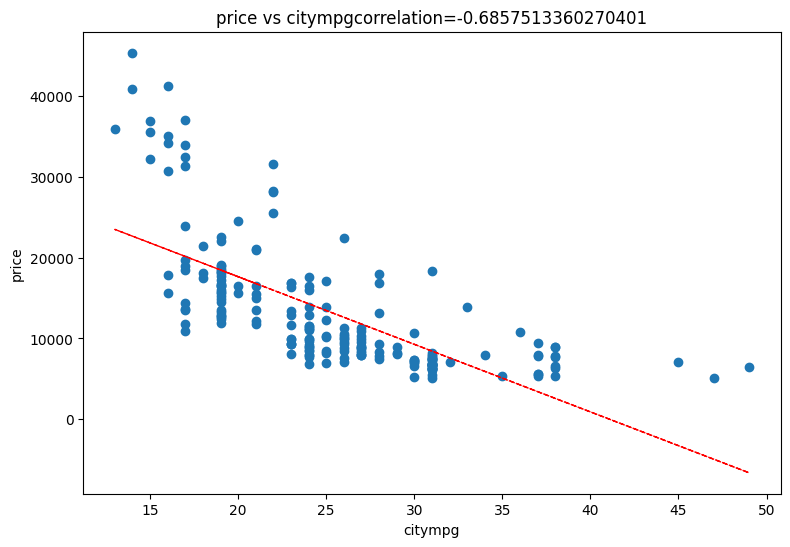

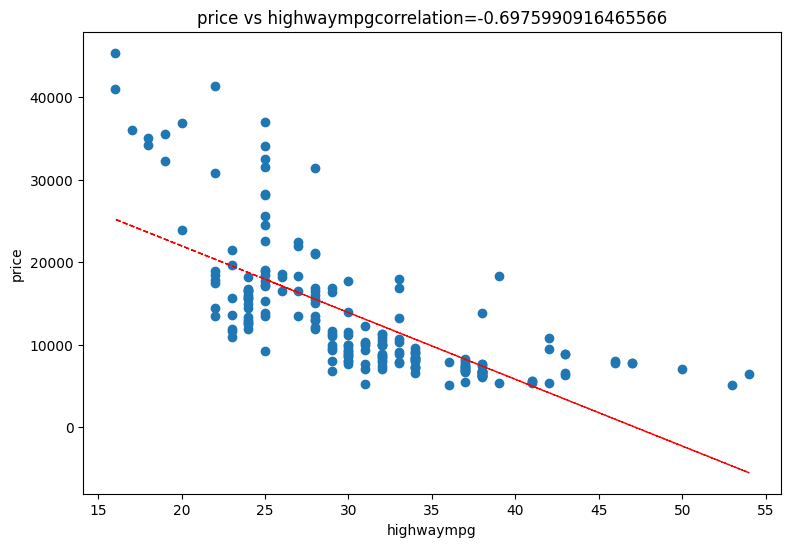

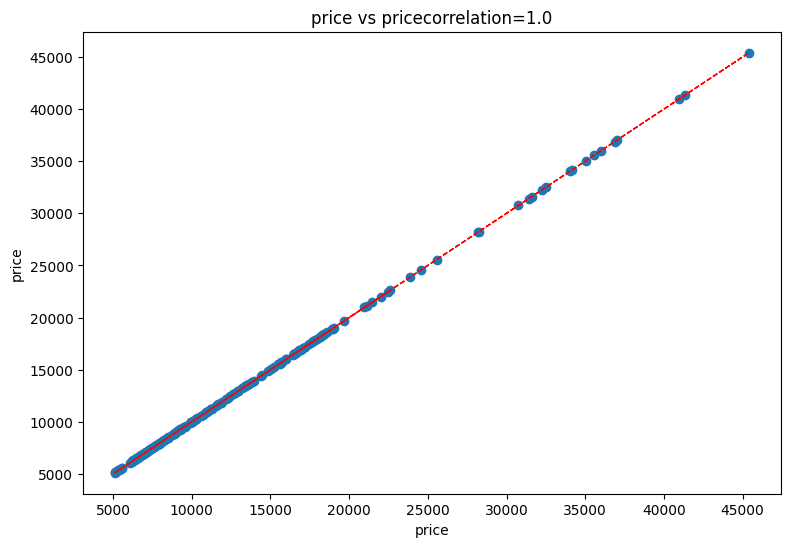

In [ ]:
for col in numeric_features:
  fig=plt.figure(figsize=(9,6))
  ax=fig.gca()
  feature=dataset[col]
  label=dataset['price']
  correlation=feature.corr(label)
  plt.scatter(x=feature,y=label)
  plt.xlabel(col)
  plt.ylabel('price')
  ax.set_title('price vs '+col+'correlation='+str(correlation))
  z=np.polyfit(dataset[col],dataset['price'],1)
  y_hat=np.poly1d(z)(dataset[col])
  plt.plot(dataset[col],y_hat,"r--",lw=1)
plt.show()

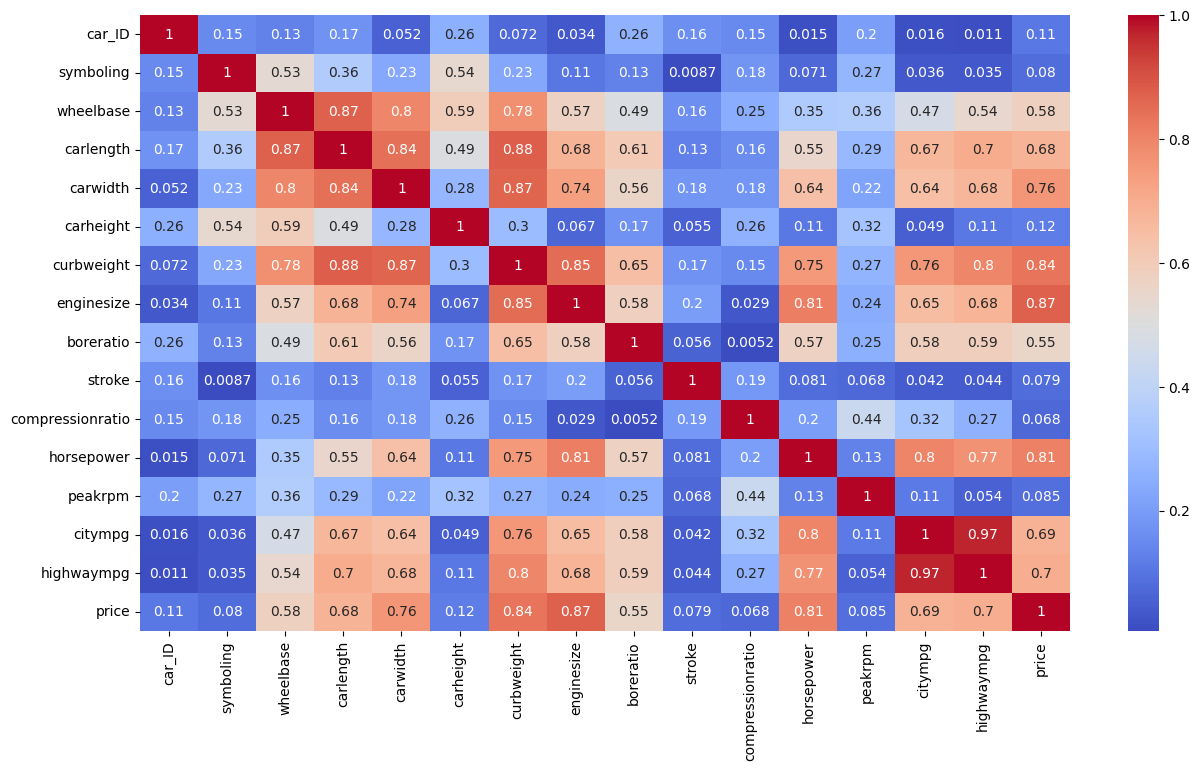

In [ ]:
plt.figure(figsize=(15,8))
correlation = dataset.select_dtypes(include=[np.number]).corr()
sns.heatmap(abs(correlation),annot=True,cmap='coolwarm')
plt.show()

In [ ]:
dataset['mileage']=0.6*dataset['citympg']+0.4*dataset['highwaympg']
dataset['car_area']=dataset['carlength']*dataset['carwidth']

In [ ]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
def calc_vif(X):
  vif=pd.DataFrame()
  vif['variables']=X.columns
  vif['VIF']=[variance_inflation_factor(X.values,i) for i in range(X.shape[1])]
  return(vif)

In [ ]:
calc_vif(dataset[[i for i in dataset.describe().columns if i not in ['car_id','price']]])

,variables,VIF
0,car_ID,5.232020
1,symboling,2.648757
2,wheelbase,2325.868367
3,carlength,6176.908824
4,carwidth,3214.216698
5,carheight,1118.432672
6,curbweight,415.678499
7,enginesize,71.426326
8,boreratio,344.049870
9,stroke,133.192613


In [ ]:
calc_vif(dataset[[i for i in dataset.describe().columns if i not in ['car_id','price',"carlenghth","carwidth","citympg","highwaympg","wheelbase","carheight","car_area"]]])

,variables,VIF
0,car_ID,5.068744
1,symboling,1.860143
2,carlength,810.596686
3,curbweight,363.603875
4,enginesize,68.404780
5,boreratio,271.286591
6,stroke,119.668962
7,compressionratio,15.500868
8,horsepower,55.595427
9,peakrpm,184.118795


In [ ]:
calc_vif(dataset[[i for i in dataset.describe().columns if i not in['car_id','symboling','price','citympg','highwaympg','company_cat','price_mean','car_width','carlength','carheight','car_vol','car_den','wheelbase','car_area','peakrpm','stroke','horsepower','boreratio','curbweight','compressionratio']]])


,variables,VIF
0,car_ID,4.067433
1,carwidth,83.027264
2,enginesize,22.174765
3,mileage,28.068512


In [ ]:
numerical_features=['enginesize','mileage','symboling']

In [ ]:
dataset['CarName'].unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

In [ ]:
dataset['company']=dataset['CarName'].str.split(" ",expand=True)[0]
dataset['company']=dataset['company'].replace({'toyouta': 'toyota','vw':'volkswagen','vokswagen':'volkswagen','maxda':'mazda','porcshce':'porsche'})
dataset['company']=dataset['company'].str.title()
dataset['company'].value_counts()

,count
company,
Toyota,32
Nissan,18
Mazda,17
Mitsubishi,13
Honda,13
Subaru,12
Volkswagen,12
Volvo,11
Peugeot,11


In [ ]:
categorical_features=dataset.describe(include=['object','category']).columns

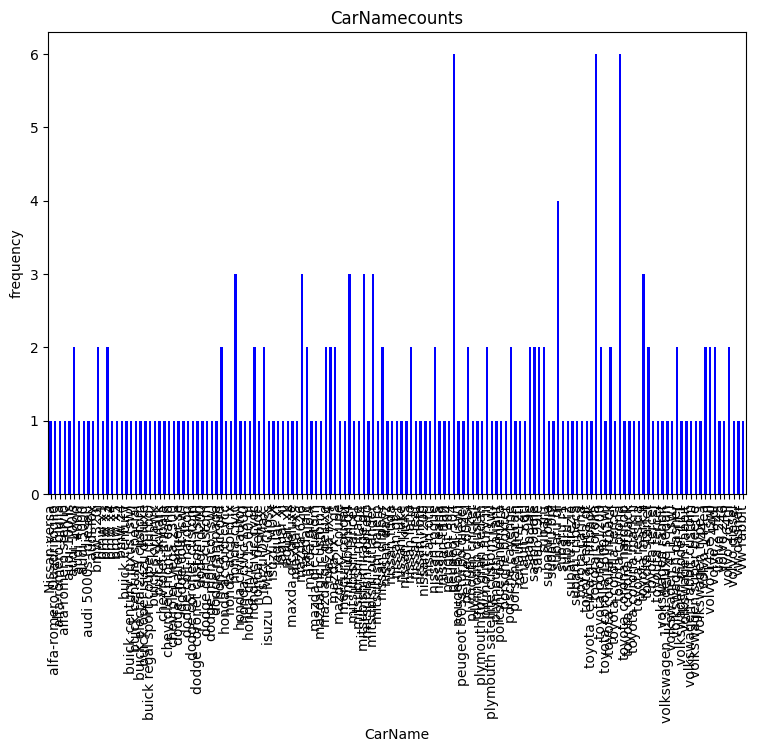

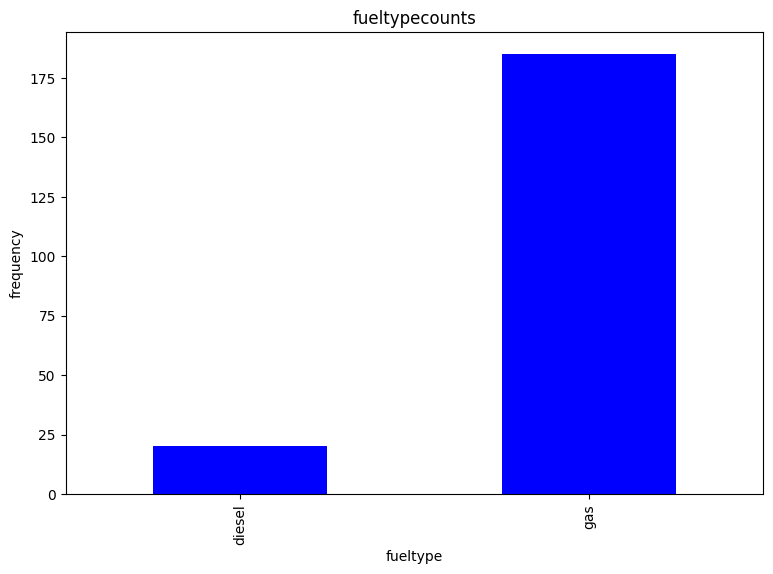

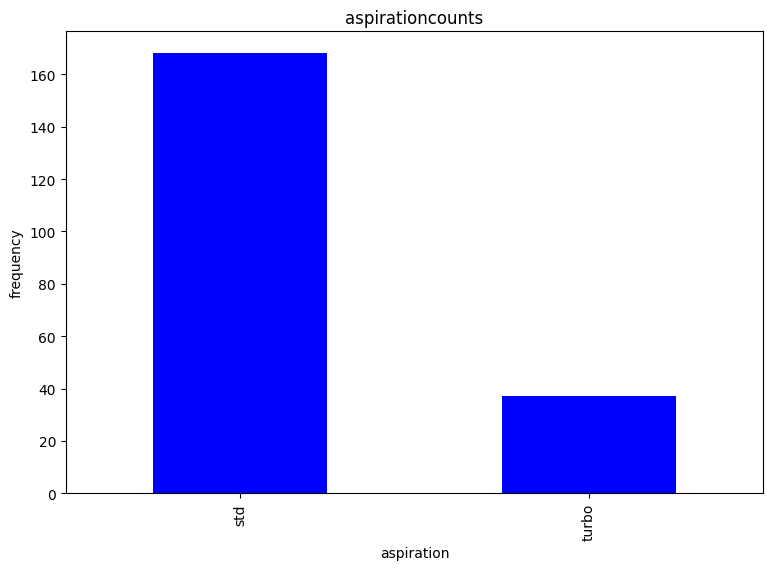

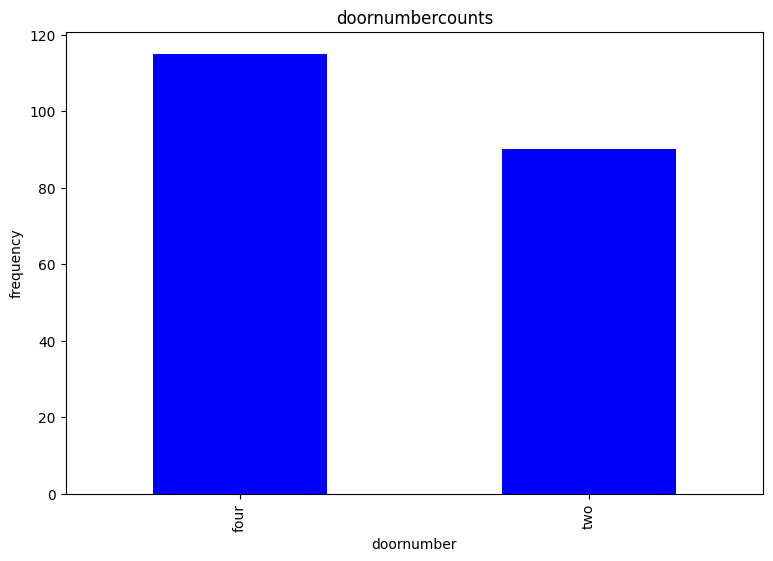

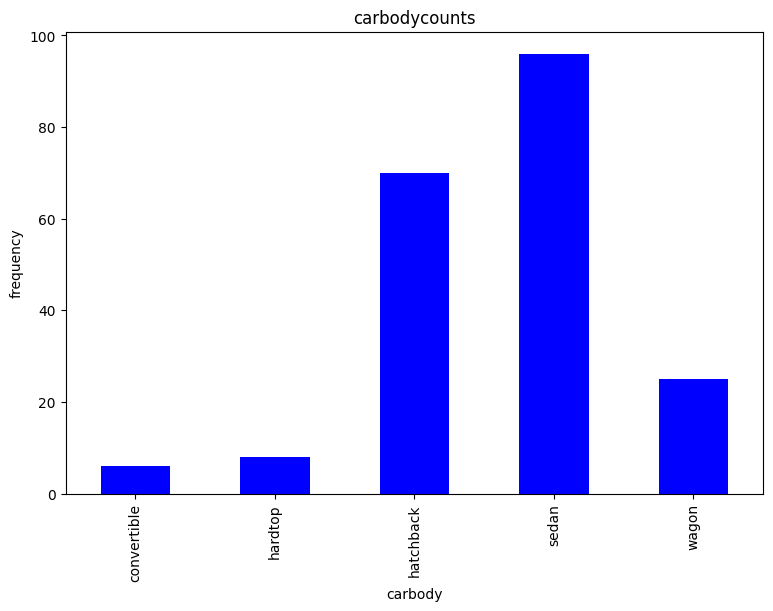

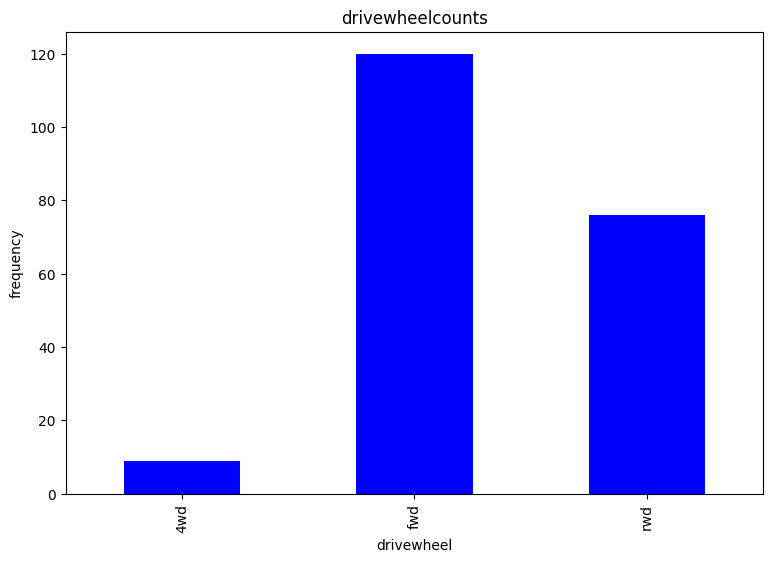

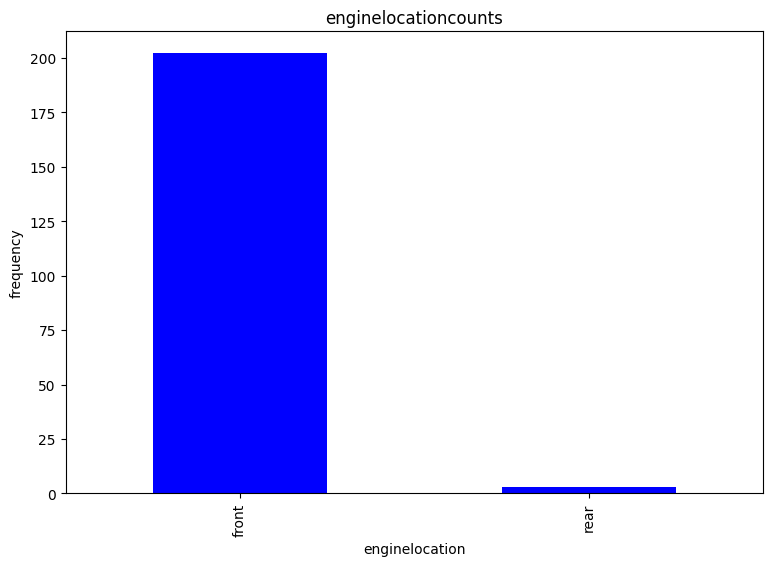

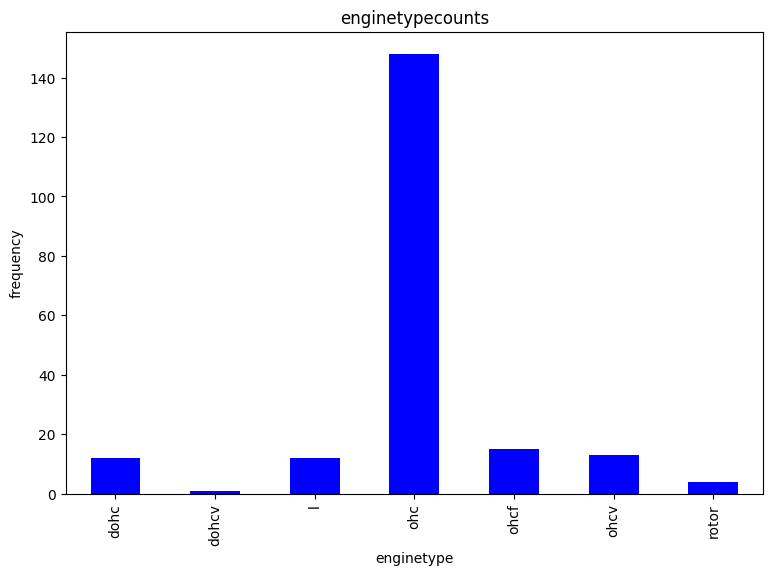

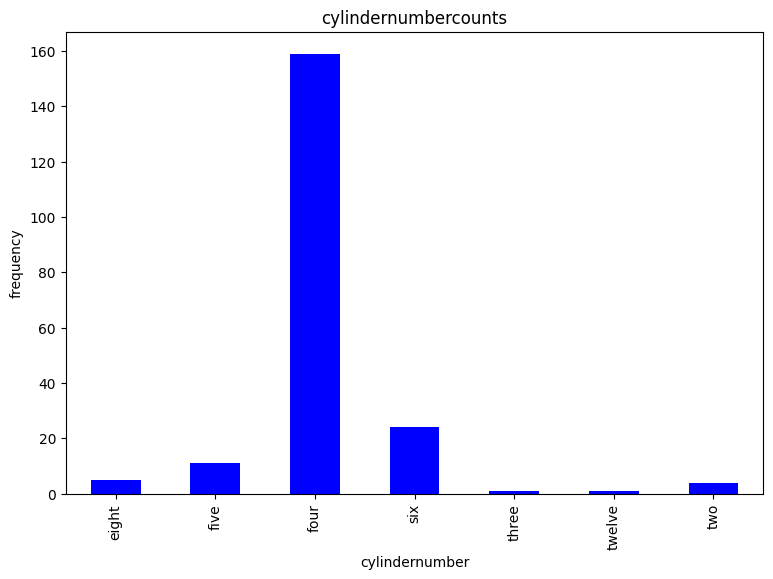

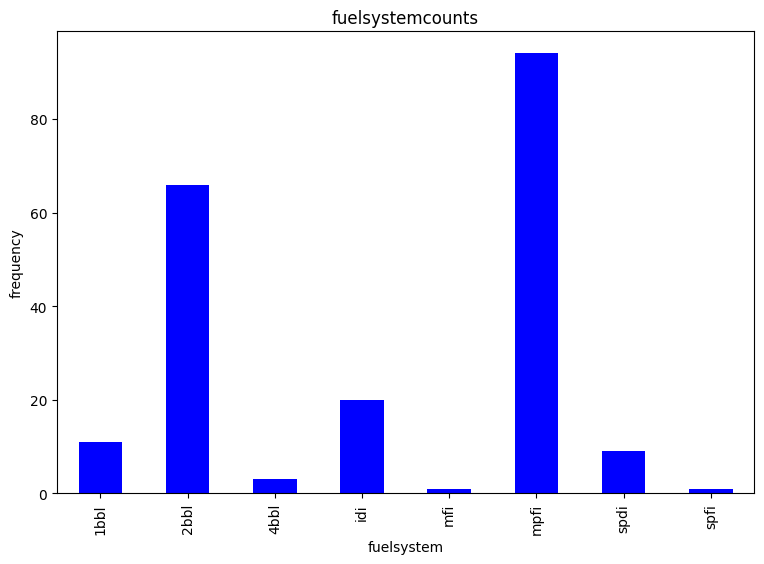

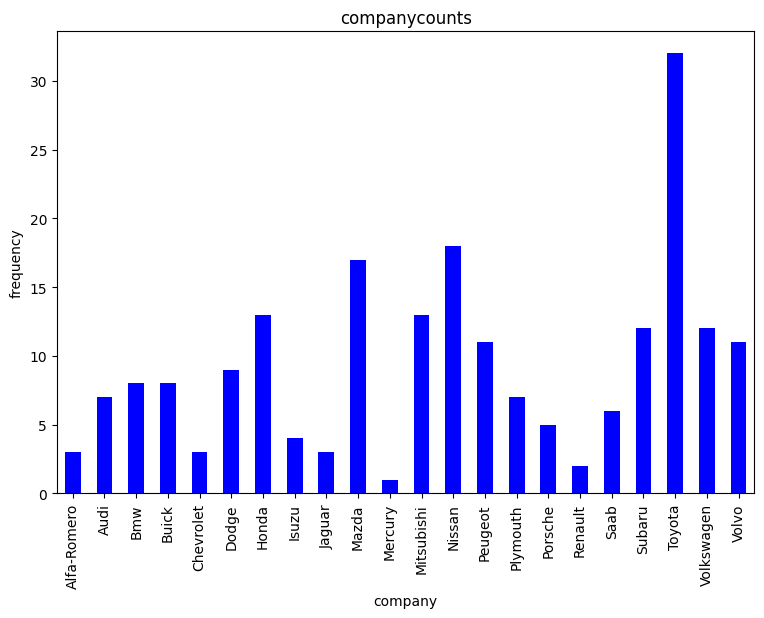

In [ ]:
for col in categorical_features:
  counts=dataset[col].value_counts().sort_index()
  fig=plt.figure(figsize=(9,6))
  ax=fig.gca()
  counts.plot.bar(ax=ax,color='b')
  ax.set_title(col+'counts')
  ax.set_xlabel(col)
  ax.set_ylabel("frequency")

In [ ]:
dataset["enginelocation"].value_counts()

,count
enginelocation,
front,202
rear,3


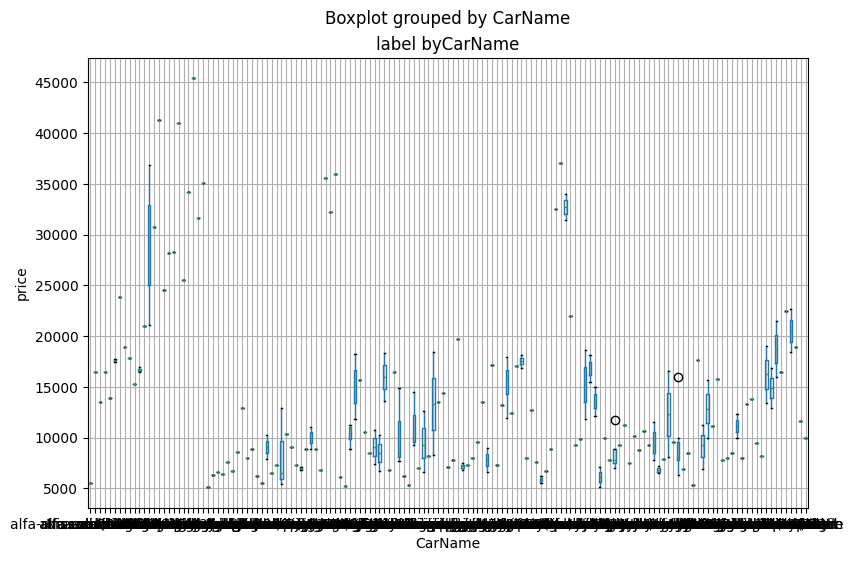

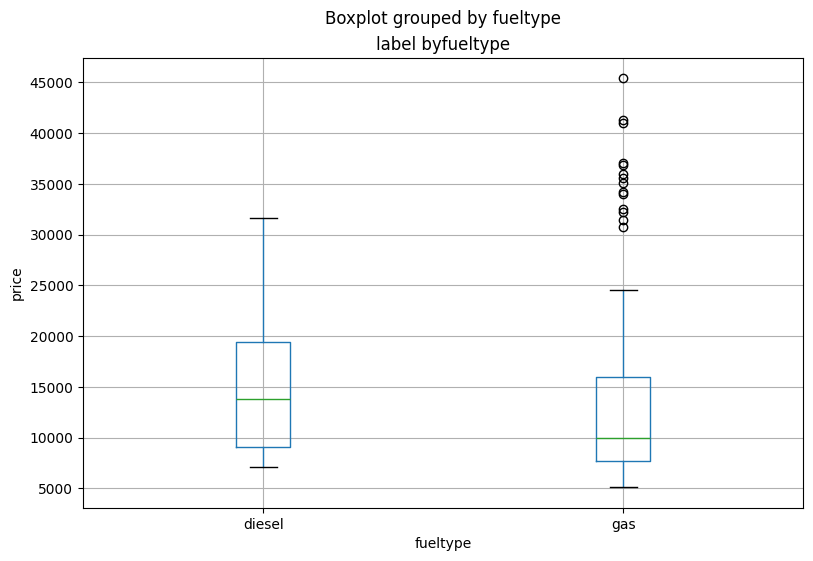

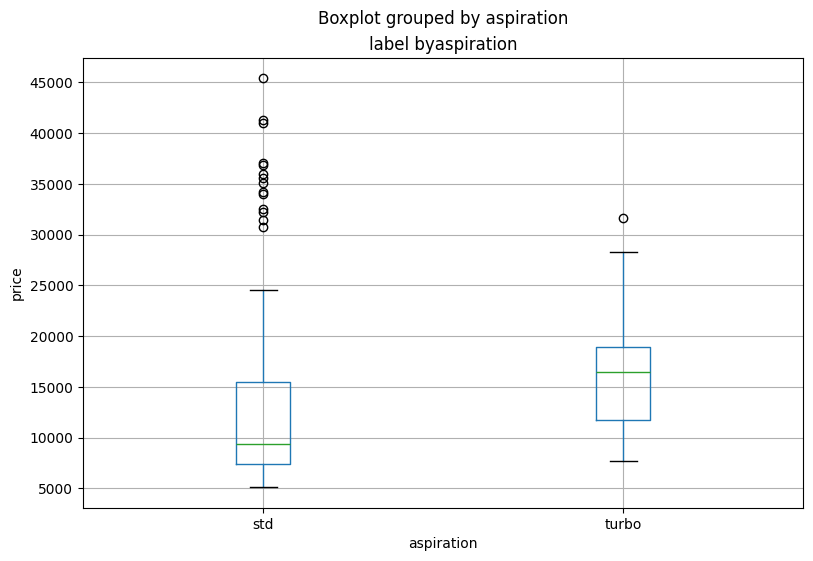

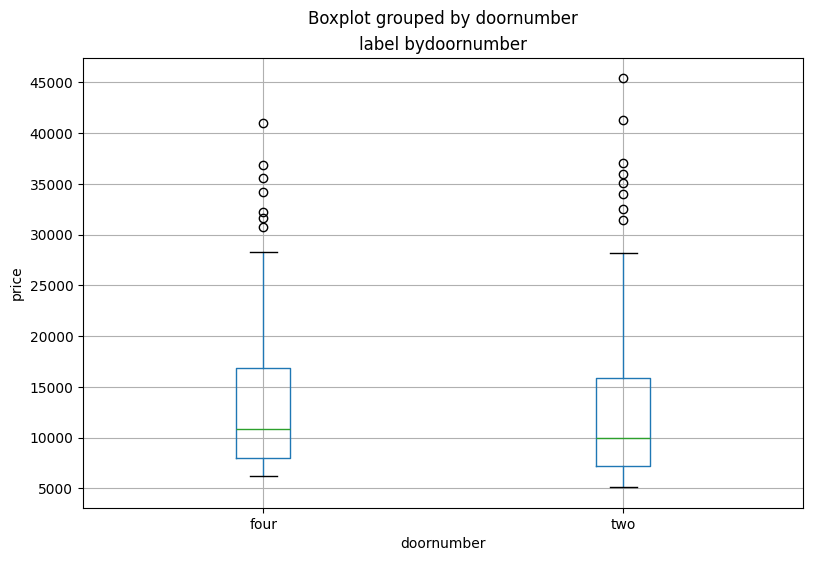

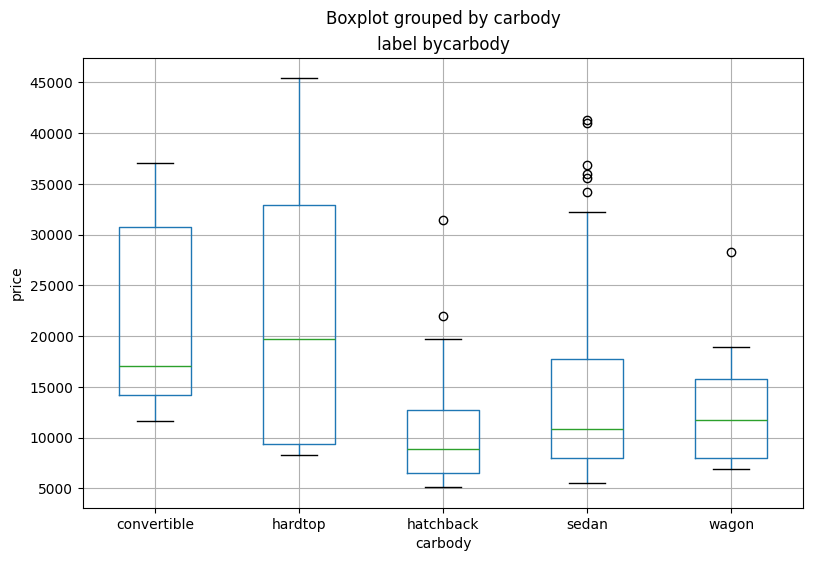

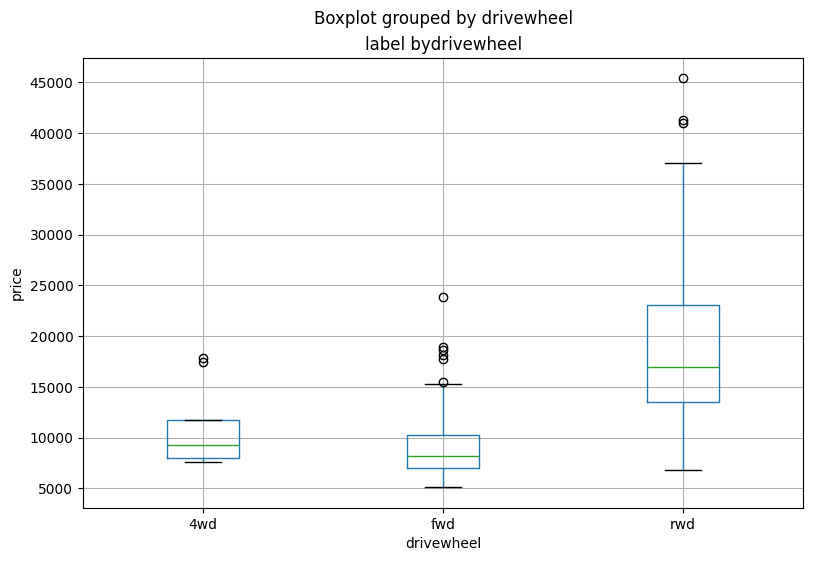

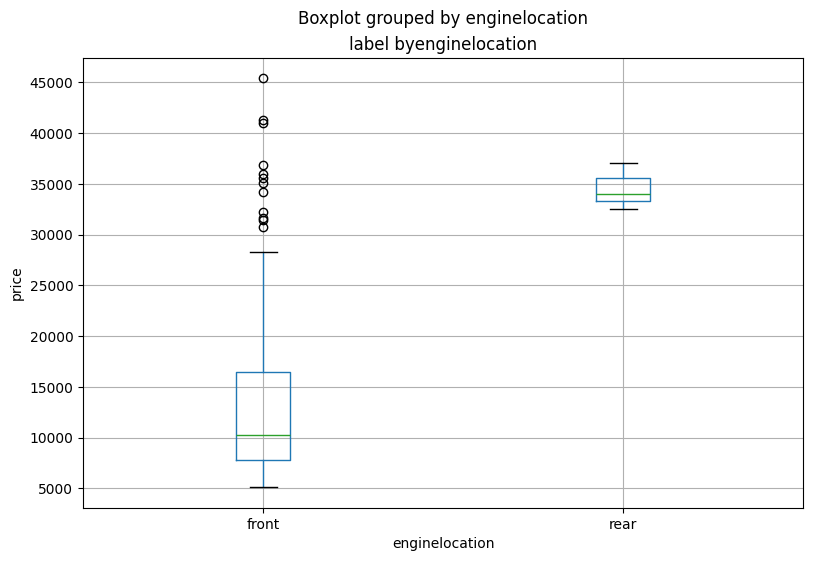

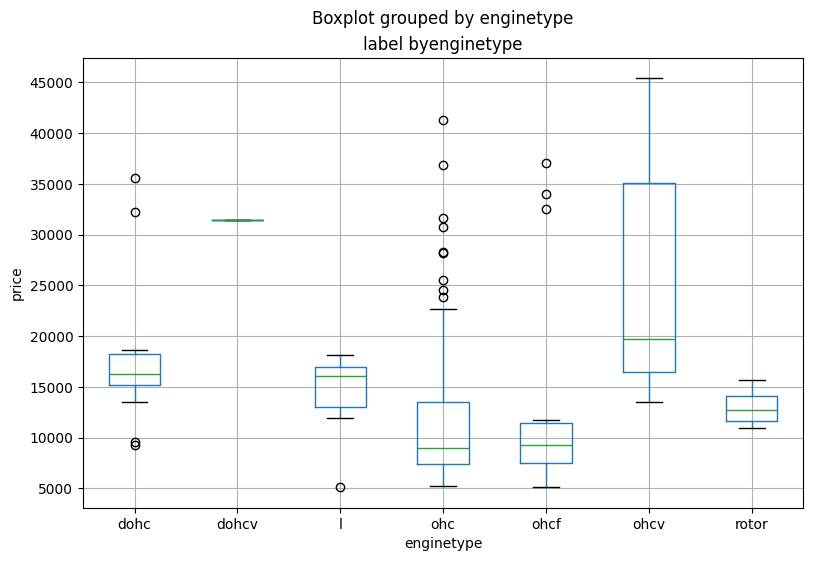

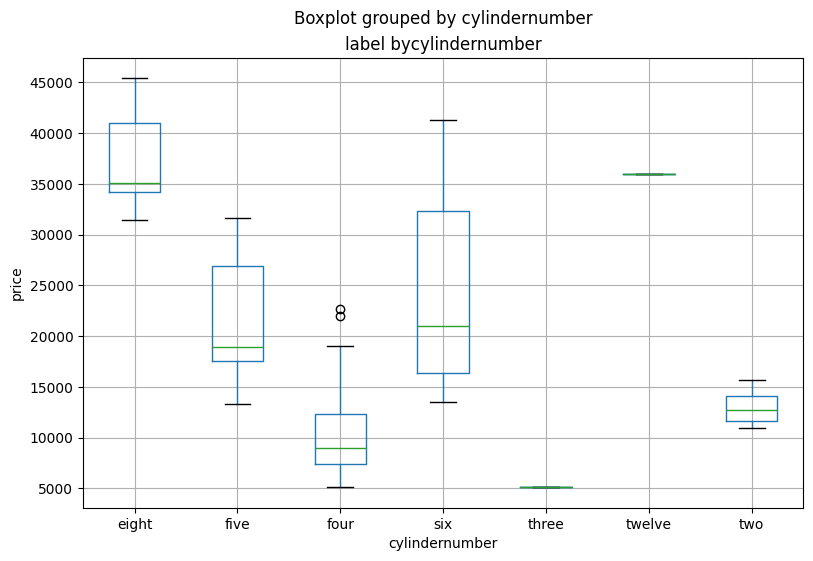

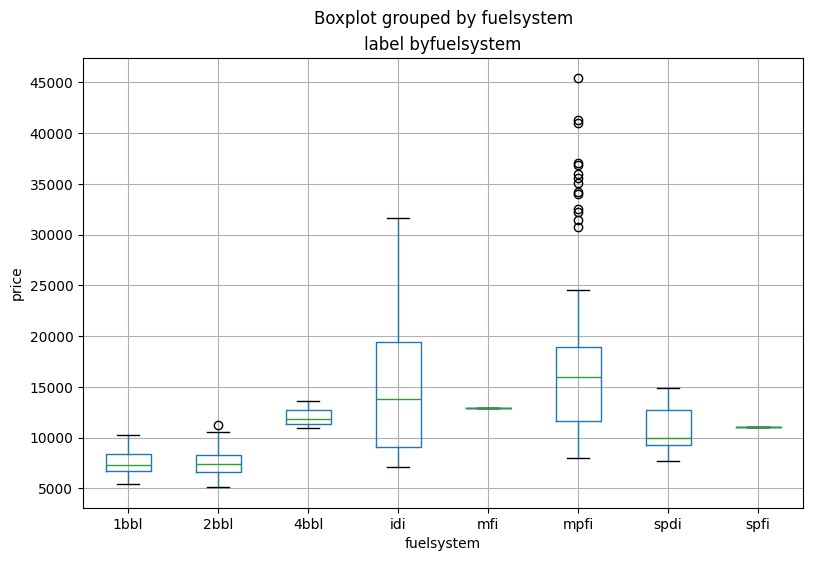

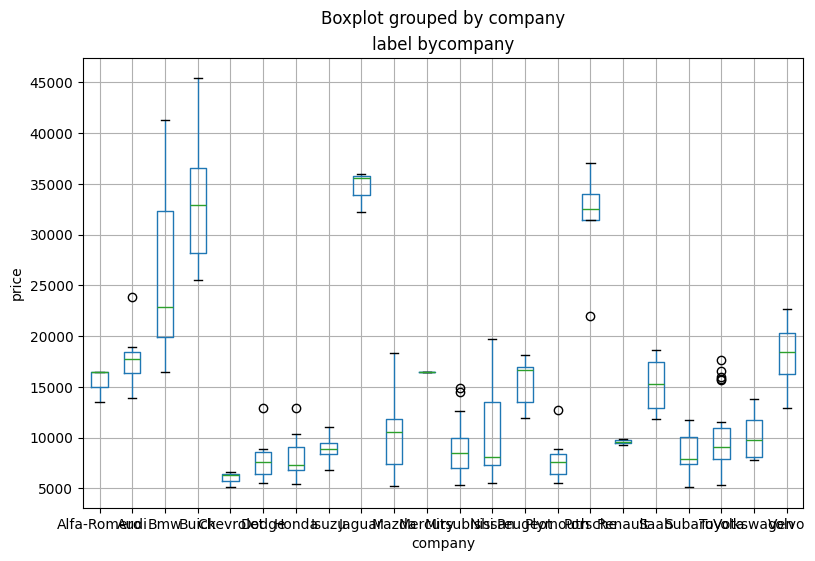

In [ ]:
for col in categorical_features:
  fig=plt.figure(figsize=(9,6))
  ax=fig.gca()
  dataset.boxplot(column='price',by=col,ax=ax)
  ax.set_title('label by'+col)
  ax.set_ylabel('price')
  plt.show()

<Figure size 2000x600 with 0 Axes>

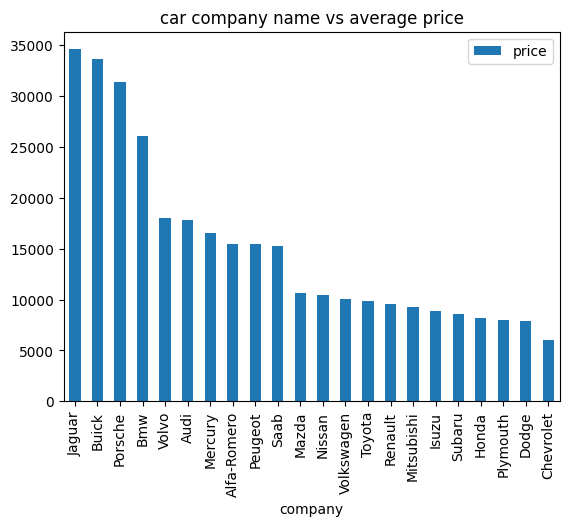

In [ ]:
plt.figure(figsize=(20,6))
df_autox=pd.DataFrame(dataset.groupby(['company'])['price'].mean().sort_values(ascending=False))
df_autox.plot.bar()
plt.title('car company name vs average price')
plt.show()

In [ ]:
df_autox.rename(columns={'price':'price_mean'},inplace=True)

In [ ]:
dataset=dataset.merge(df_autox,on='company',how='left')

In [ ]:
dataset['company_cat']=dataset['price_mean'].apply(lambda x:0 if x>12000 else (1 if 12000 <= x<24000else 2))

In [ ]:
dataset["company_cat"].value_counts()

,count
company_cat,
2,142
0,63


In [ ]:
correlation.price

,price
car_ID,-0.109093
symboling,-0.079978
wheelbase,0.577816
carlength,0.682920
carwidth,0.759325
carheight,0.119336
curbweight,0.835305
enginesize,0.874145
boreratio,0.553173
stroke,0.079443


In [ ]:
dataset_pr=dataset.copy()

In [ ]:
encoders_nums={"fueltype":{"diesel":1,"gas":0},"aspiration":{"turbo":1,"std":0},"doornumber":{"four":4,"two":2},"drivewheel":{"fwd":0,"4wd":0,"rwd":1},"cylindernumber":{"four":4,"six":6,"five":5,"eight":8,"two":2,"twelve":12,"three":3}}
dataset_pr=dataset_pr.replace(encoders_nums)

In [ ]:
target_cols = ["carbody","enginetype","fuelsystem"]
target_prefixes = ["body","etype","fsystem"]

cols_to_encode = []
prefixes_for_encoding = []

for i, col_name in enumerate(target_cols):
    if col_name in dataset_pr.columns and dataset_pr[col_name].dtype == 'object':
        cols_to_encode.append(col_name)
        prefixes_for_encoding.append(target_prefixes[i])

if cols_to_encode:
    dataset_pr = pd.get_dummies(dataset_pr, columns=cols_to_encode, prefix=prefixes_for_encoding)

In [ ]:
dataset_pr.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,drivewheel,enginelocation,wheelbase,carlength,...,etype_ohcv,etype_rotor,fsystem_1bbl,fsystem_2bbl,fsystem_4bbl,fsystem_idi,fsystem_mfi,fsystem_mpfi,fsystem_spdi,fsystem_spfi
0,1,3,alfa-romero giulia,0,0,2,1,front,88.6,168.8,...,False,False,False,False,False,False,False,True,False,False
1,2,3,alfa-romero stelvio,0,0,2,1,front,88.6,168.8,...,False,False,False,False,False,False,False,True,False,False
2,3,1,alfa-romero Quadrifoglio,0,0,2,1,front,94.5,171.2,...,True,False,False,False,False,False,False,True,False,False
3,4,2,audi 100 ls,0,0,4,0,front,99.8,176.6,...,False,False,False,False,False,False,False,True,False,False
4,5,2,audi 100ls,0,0,4,0,front,99.4,176.6,...,False,False,False,False,False,False,False,True,False,False


In [ ]:
features=numerical_features.copy()
features.extend(['fueltype','aspiration','doornumber','drivewheel','cylindernumber', 'company_cat','body_convertible','body_hardtop','body_hatchback','body_sedan','body_wagon','etype_dohc','etype_ohcv','etype_l','etype_ohc','etype_ohcf','etype_ohcv','fsystem_1bbl','fsystem_2bbl','fsystem_idi','fsystem_mpfi','fsystem_spdi'])

In [ ]:
features

['enginesize',
 'mileage',
 'symboling',
 'fueltype',
 'aspiration',
 'doornumber',
 'drivewheel',
 'cylindernumber',
 'company_cat',
 'body_convertible',
 'body_hardtop',
 'body_hatchback',
 'body_sedan',
 'body_wagon',
 'etype_dohc',
 'etype_ohcv',
 'etype_l',
 'etype_ohc',
 'etype_ohcf',
 'etype_ohcv',
 'fsystem_1bbl',
 'fsystem_2bbl',
 'fsystem_idi',
 'fsystem_mpfi',
 'fsystem_spdi']

In [ ]:
len(features)

25

In [ ]:
from scipy.stats import zscore
#train test split
#numeric_cols=carprice.select_dtypes(include=[np.number]).columns
x=dataset_pr[features].apply(zscore)

In [ ]:
y=np.log10(dataset_pr['price'])

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=0)
print(x_train.shape)
print(x_test.shape)

(164, 25)
(41, 25)


In [ ]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression().fit(x_train,y_train)


In [ ]:
reg.score(x_train,y_train)

0.9283951718922229

In [ ]:
reg.coef_

array([ 0.08811332, -0.05253132,  0.00990732,  0.01236366,  0.01838593,
        0.01986495,  0.02131395,  0.01542461, -0.05295551,  0.01264457,
        0.00089431, -0.00131998,  0.00133844, -0.0071707 , -0.05267683,
       -0.03109976, -0.06769385, -0.08015617, -0.04268792, -0.03109976,
        0.00440362, -0.01031037,  0.01236366,  0.02032373, -0.00571692])

In [ ]:
len(reg.coef_)

25

In [ ]:
reg.intercept_

np.float64(4.059341667404531)

In [ ]:
y_pred=reg.predict(x_test)

In [ ]:
y_pred

array([3.80982707, 4.15497872, 4.20909523, 3.50656492, 4.00720117,
       4.10759531, 3.78181755, 3.8629777 , 4.17439557, 3.87102252,
       4.29191707, 4.60371931, 4.11204061, 4.0849099 , 3.79600522,
       4.10019361, 4.03290599, 4.21655305, 3.9186926 , 3.85197685,
       3.97155786, 4.12277942, 4.02795752, 4.10019361, 4.18719182,
       3.85186328, 3.87013291, 4.09818378, 3.88371997, 3.83119511,
       3.95605831, 3.97459384, 4.26689286, 3.99020941, 3.87122377,
       4.43023639, 4.06653468, 4.16462744, 3.80770595, 4.62252702,
       3.76395176])

y-test

In [ ]:
from sklearn.metrics import mean_squared_error
mse=mean_squared_error(10**(y_test),10**(y_pred))
print("mse:",mse)
rmse=np.sqrt(mse)
print("rmse:",rmse)

mse: 11098761.752145495
rmse: 3331.4804144922564


In [ ]:
from sklearn.metrics import r2_score
r2=r2_score(10**(y_test),10**(y_pred))
print("r2:",r2)
print("adjusted r2:",1-(1-r2_score(10**(y_test),10**(y_pred)))*((x_test.shape[0]-1)/(x_test.shape[0]-x_test.shape[1]-1)))

r2: 0.8566354449237789
adjusted r2: 0.6176945197967436


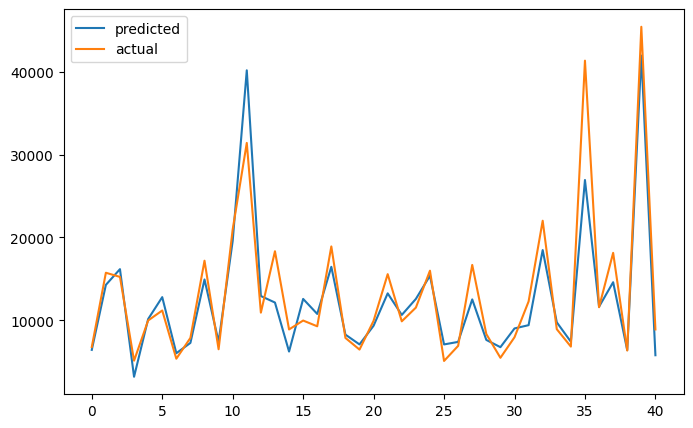

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(10**(y_pred))
plt.plot(np.array(10**(y_test)))
plt.legend(['predicted','actual'])
plt.show()

In [ ]:
from sklearn.linear_model import Lasso
lasso_model = Lasso(alpha=0.0001,max_iter=3000)
lasso_model.fit(x_train,y_train)

Lasso(alpha=0.0001, max_iter=3000)

In [ ]:
lasso_model.score(x_train,y_train)

0.9283255178016037

In [ ]:
lasso_model.coef_

array([ 0.0875785 , -0.05338469,  0.00980482,  0.02282452,  0.01764408,
        0.01942729,  0.0216529 ,  0.01417281, -0.05307424,  0.01186925,
        0.00018837, -0.00262857,  0.        , -0.00806978, -0.04818575,
       -0.01959679, -0.06346873, -0.07200657, -0.03772482, -0.03731391,
        0.00260028, -0.01389821,  0.00010078,  0.01638135, -0.00706547])

In [ ]:
from sklearn.model_selection import GridSearchCV
lasso_model=Lasso() # Corrected: changed 'lasso()' to 'Lasso()'
parameters={'alpha': [1e-15,1e-13,1e-10,1e-8,1e-5,1e-4,1e-3,1e-2,1e-1,1,5,10,20,30,40,45,50,55,60,100,0.0014]}
lasso_model_regressor=GridSearchCV(lasso_model,parameters,scoring='neg_mean_squared_error',cv=5)
lasso_model_regressor.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=Lasso(),
             param_grid={'alpha': [1e-15, 1e-13, 1e-10, 1e-08, 1e-05, 0.0001,
                                   0.001, 0.01, 0.1, 1, 5, 10, 20, 30, 40, 45,
                                   50, 55, 60, 100, 0.0014]},
             scoring='neg_mean_squared_error')

In [ ]:
print("the best fit alpha value is found out to be:",lasso_model_regressor.best_params_)
print("\nusing",lasso_model_regressor.best_params_,"the negative mean squared error is:",lasso_model_regressor.best_score_)

the best fit alpha value is found out to be: {'alpha': 0.0014}

using {'alpha': 0.0014} the negative mean squared error is: -0.005406446240154695


In [ ]:
y_pred_lasso=lasso_model_regressor.predict(x_test)

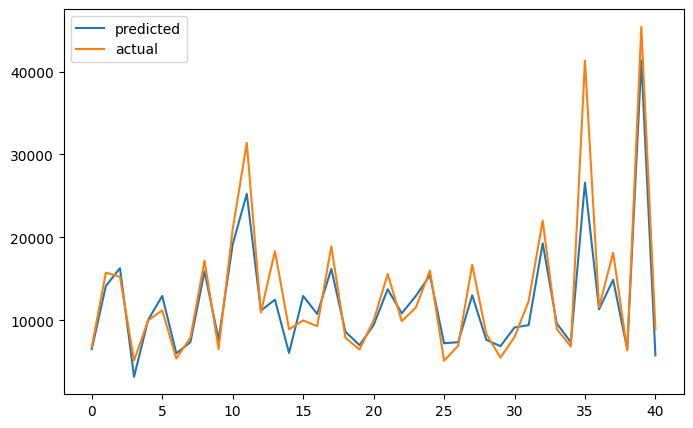

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(10**(y_pred_lasso))
plt.plot(10**(np.array(y_test)))
plt.legend(['predicted','actual'])
plt.show()

In [ ]:
mse=mean_squared_error(10**(y_test),10**(y_pred_lasso))
print("mse:",mse)
rmse=np.sqrt(mse)
print("rmse:",rmse)
r2=r2_score(10**(y_test),10**(y_pred_lasso))
print("r2:",r2)
print("adjusted r2:",1-(1-r2_score(10**(y_test),10**(y_pred_lasso)))*((x_test.shape[0]-1)/(x_test.shape[0]-x_test.shape[1]-1)))

mse: 10137732.960784087
rmse: 3183.9806784564644
r2: 0.869049213969892
adjusted r2: 0.650797903919712


In [ ]:
from sklearn.linear_model import Ridge
ridge_model=Ridge()
parameters={'alpha':[1e-15,1e-10,1e-8,1e-4,1e-3,1e-2,1,5,10,20,30,40,45,50,55,60,100]}
ridge_model_regressor=GridSearchCV(ridge_model,parameters,scoring='neg_mean_squared_error',cv=3)
ridge_model_regressor.fit(x_train,y_train)

GridSearchCV(cv=3, estimator=Ridge(),
             param_grid={'alpha': [1e-15, 1e-10, 1e-08, 0.0001, 0.001, 0.01, 1,
                                   5, 10, 20, 30, 40, 45, 50, 55, 60, 100]},
             scoring='neg_mean_squared_error')

In [ ]:
print("the best fit alpha value is found out to be:",ridge_model_regressor.best_params_)
print("\nusing",ridge_model_regressor.best_params_,"the negative mean squared error is:",ridge_model_regressor.best_score_)

the best fit alpha value is found out to be: {'alpha': 10}

using {'alpha': 10} the negative mean squared error is: -0.0059842064378050645


In [ ]:
y_pred_ridge=ridge_model_regressor.predict(x_test)

In [ ]:
mse=mean_squared_error(10**(y_test),10**(y_pred_ridge))
print("mse:",mse)
rmse=np.sqrt(mse)
print("rmse:",rmse)
r2=r2_score(10**(y_test),10**(y_pred_ridge))
print("r2:",r2)
print("adjusted r2:",1-(1-r2_score(10**(y_test),10**(y_pred_ridge)))*((x_test.shape[0]-1)/(x_test.shape[0]-x_test.shape[1]-1)))

mse: 10626006.135614313
rmse: 3259.7555331058666
r2: 0.8627421080036198
adjusted r2: 0.6339789546763196


In [ ]:
from sklearn.linear_model import ElasticNet
#a*l1+b*l2
#alpha=a+b and l1_ratio=a/(a+b)
elastic_net_instance=ElasticNet(alpha=0.1,l1_ratio=0.5)

In [ ]:
elastic_net_instance.fit(x_train,y_train)

ElasticNet(alpha=0.1)

In [ ]:
elastic_net_instance.score(x_train,y_train)

0.7939314511206343

In [ ]:
y_pred_en=elastic_net_instance.predict(x_test)

In [ ]:
mse=mean_squared_error(10**(y_test),10**(y_pred_en))
print("mse:",mse)
rmse=np.sqrt(mse)
print("rmse:",rmse)
r2=r2_score(10**(y_test),10**(y_pred_en))
print("r2:",r2)
print("adjusted r2:",1-(1-r2_score(10**(y_test),10**(y_pred_en)))*((x_test.shape[0]-1)/(x_test.shape[0]-x_test.shape[1]-1)))

mse: 23160277.827278186
rmse: 4812.512631388949
r2: 0.7008348318218878
adjusted r2: 0.20222621819170072


In [ ]:
elastic_model=ElasticNet()
parameters ={'alpha':[1e-15,1e-13,1e-10,1e-8,1e-5,1e-4,1e-3,1e-2,1e-1,1,5,10,20,30,40,45,50,60,100],'l1_ratio':[0.3,0.4,0.5,0.6,0.7,0.8]}
elastic_regressor=GridSearchCV(elastic_model,parameters,scoring='neg_mean_squared_error',cv=5)
elastic_regressor.fit(x_train,y_train)

GridSearchCV(cv=5, estimator=ElasticNet(),
             param_grid={'alpha': [1e-15, 1e-13, 1e-10, 1e-08, 1e-05, 0.0001,
                                   0.001, 0.01, 0.1, 1, 5, 10, 20, 30, 40, 45,
                                   50, 60, 100],
                         'l1_ratio': [0.3, 0.4, 0.5, 0.6, 0.7, 0.8]},
             scoring='neg_mean_squared_error')

In [ ]:
print("the best fit alpha value is found out be:",elastic_regressor.best_params_)
print("\nusing",elastic_regressor.best_params_,"the negative mean squared error is:",elastic_regressor.best_score_)

the best fit alpha value is found out be: {'alpha': 0.01, 'l1_ratio': 0.3}

using {'alpha': 0.01, 'l1_ratio': 0.3} the negative mean squared error is: -0.005513492158033176


In [ ]:
y_pred_elastic=elastic_regressor.predict(x_test)

In [ ]:
mse=mean_squared_error(10**(y_test),10**(y_pred_elastic))
print("mse:",mse)
rmse=np.sqrt(mse)
print("rmse:",rmse)
r2=r2_score(10**(y_test),10**(y_pred_elastic))
print("r2:",r2)
print("adjusted r2:",1-(1-r2_score(10**(y_test),10**(y_pred_elastic)))*((x_test.shape[0]-1)/(x_test.shape[0]-x_test.shape[1]-1)))

mse: 10547280.023212714
rmse: 3247.657620995895
r2: 0.8637590263166157
adjusted r2: 0.6366907368443087


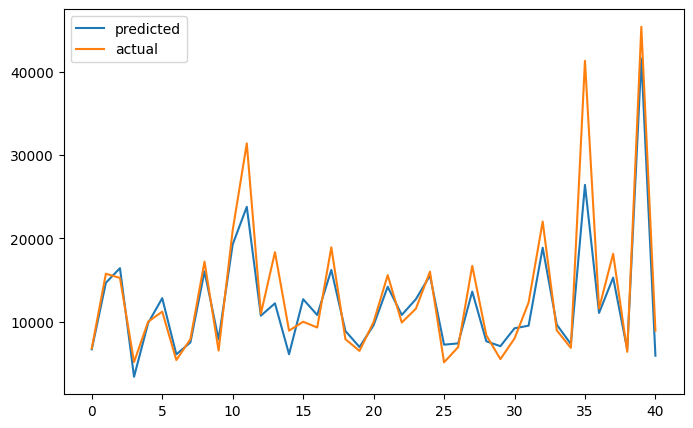

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(10**(y_pred_elastic))
plt.plot(10**(np.array(y_test)))
plt.legend(['predicted','actual'])
plt.show()